<a href="https://colab.research.google.com/github/aaronGeb/ml-zoomcamp/blob/main/deep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/aaronGeb/ml-zoomcamp

Cloning into 'ml-zoomcamp'...
remote: Enumerating objects: 3940, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 3940 (delta 49), reused 119 (delta 48), pack-reused 3819 (from 1)
Receiving objects: 100% (3940/3940), 102.53 MiB | 16.62 MiB/s, done.
Resolving deltas: 100% (50/50), done.


In [3]:
path = '/content/ml-zoomcamp/deep_learning/train/t-shirt/1.jpg'

In [2]:
import tensorflow  as tf

In [3]:
from tensorflow import keras
from tensorflow.keras.preprocessing.image  import load_img
import numpy as np

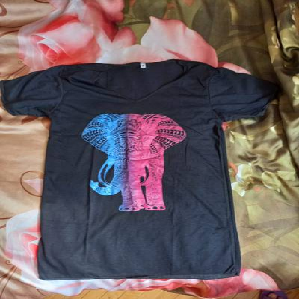

In [4]:
path = path = '/content/ml-zoomcamp/deep_learning/train/t-shirt'
name = '1.jpg'
full_path = path + '/' + name
img = load_img(full_path, target_size=(299, 299))
img

In [5]:
print(img)

<PIL.Image.Image image mode=RGB size=299x299 at 0x78726080F580>


array([[[133,  96,  80],
        [138, 101,  83],
        [146, 109,  91],
        ...,
        [ 60,  43,  27],
        [ 65,  48,  32],
        [ 66,  49,  33]],

       [[144, 107,  89],
        [142, 105,  87],
        [147, 110,  92],
        ...,
        [ 67,  50,  32],
        [ 66,  49,  29],
        [ 63,  45,  25]],

       [[155, 116,  99],
        [148, 111,  93],
        [144, 107,  89],
        ...,
        [ 67,  51,  26],
        [ 53,  35,  11],
        [ 68,  48,  24]],

       ...,

       [[128,  85,  76],
        [177, 137, 127],
        [183, 143, 131],
        ...,
        [103,  54,  22],
        [110,  62,  26],
        [102,  54,  14]],

       [[130,  90,  80],
        [170, 130, 120],
        [171, 131, 121],
        ...,
        [104,  55,  23],
        [106,  58,  22],
        [102,  55,  11]],

       [[135,  95,  85],
        [161, 121, 111],
        [159, 119, 109],
        ...,
        [105,  56,  24],
        [103,  55,  19],
        [103,  56,  12]]], dtype=uint8)
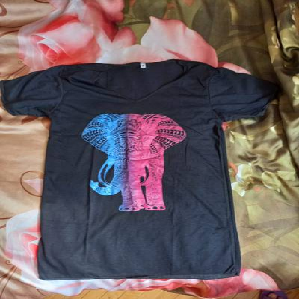

In [6]:
np.array(img)

In [7]:
x = np.array(img)
x.shape

(299, 299, 3)

In [8]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [9]:

model = Xception(weights='imagenet', input_shape=(299, 299, 3))

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [10]:
X = np.array([x])

In [11]:
X.shape

(1, 299, 299, 3)

In [12]:
X = preprocess_input(X)

In [13]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [14]:
decode_predictions(pred)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


[[('n03595614', 'jersey', 0.87694055),
  ('n03710637', 'maillot', 0.009399718),
  ('n04370456', 'sweatshirt', 0.006794201),
  ('n03877472', 'pajama', 0.0046360227),
  ('n04525038', 'velvet', 0.0033033756)]]

#### 8.4 Convolutional neural networks
  - Types of layers: convolutional and dense
  - Convolutional layers and filters
  - Dense layers

In [15]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [16]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    '/content/ml-zoomcamp/deep_learning/train',
    target_size=(150, 150),
    batch_size=32
)


Found 3068 images belonging to 10 classes.


In [17]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [18]:
X, y = next(train_ds)

In [22]:
y[:5]

array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [19]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    '/content/ml-zoomcamp/deep_learning/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [20]:
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = False



inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs, training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [22]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [23]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


96/96 ━━━━━━━━━━━━━━━━━━━━ 35s 260ms/step - accuracy: 0.5668 - loss: 1.7090 - val_accuracy: 0.7566 - val_loss: 1.0693
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - accuracy: 0.8311 - loss: 0.5092 - val_accuracy: 0.7889 - val_loss: 0.8503
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.8879 - loss: 0.3278 - val_accuracy: 0.7947 - val_loss: 0.7771
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.9237 - loss: 0.2335 - val_accuracy: 0.7478 - val_loss: 1.0175
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.9276 - loss: 0.1991 - val_accuracy: 0.7566 - val_loss: 1.0165
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.9560 - loss: 0.1295 - val_accuracy: 0.7654 - val_loss: 1.2524
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.9702 - loss: 0.0880 - val_accuracy: 0.8094 - val_loss: 0.8419
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9800 - loss: 0.0656 - val_accuracy: 0.8094 - val_los

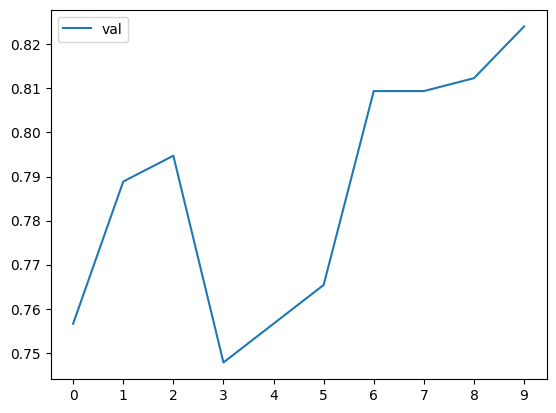

In [25]:
import matplotlib.pyplot as plt
#plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()